<a href="https://colab.research.google.com/github/TejasKayarkar03/Pattern-Recognition-Lab/blob/main/PR_CM23045_Pr_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
uploaded = files.upload()

Saving wdbc.data to wdbc (2).data


In [ ]:
column_names = [
    "ID", "Diagnosis",
    "Radius_mean", "Texture_mean", "Perimeter_mean", "Area_mean", "Smoothness_mean",
    "Compactness_mean", "Concavity_mean", "Concave_points_mean", "Symmetry_mean", "Fractal_dimension_mean",
    "Radius_se", "Texture_se", "Perimeter_se", "Area_se", "Smoothness_se",
    "Compactness_se", "Concavity_se", "Concave_points_se", "Symmetry_se", "Fractal_dimension_se",
    "Radius_worst", "Texture_worst", "Perimeter_worst", "Area_worst", "Smoothness_worst",
    "Compactness_worst", "Concavity_worst", "Concave_points_worst", "Symmetry_worst", "Fractal_dimension_worst"
]

df = pd.read_csv("wdbc.data", header=None, names=column_names)

df.head()

,ID,Diagnosis,Radius_mean,Texture_mean,Perimeter_mean,Area_mean,Smoothness_mean,Compactness_mean,Concavity_mean,Concave_points_mean,...,Radius_worst,Texture_worst,Perimeter_worst,Area_worst,Smoothness_worst,Compactness_worst,Concavity_worst,Concave_points_worst,Symmetry_worst,Fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
print("Dataset Shape:", df.shape)
print(df.info())
print(df.describe())

Dataset Shape: (569, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       569 non-null    int64  
 1   Diagnosis                569 non-null    object 
 2   Radius_mean              569 non-null    float64
 3   Texture_mean             569 non-null    float64
 4   Perimeter_mean           569 non-null    float64
 5   Area_mean                569 non-null    float64
 6   Smoothness_mean          569 non-null    float64
 7   Compactness_mean         569 non-null    float64
 8   Concavity_mean           569 non-null    float64
 9   Concave_points_mean      569 non-null    float64
 10  Symmetry_mean            569 non-null    float64
 11  Fractal_dimension_mean   569 non-null    float64
 12  Radius_se                569 non-null    float64
 13  Texture_se               569 non-null    float64
 14  P

In [ ]:
# Convert Diagnosis: M = 1, B = 0
df["Diagnosis"] = df["Diagnosis"].map({"M": 1, "B": 0})

X = df.drop(["ID", "Diagnosis"], axis=1)
y = df["Diagnosis"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (569, 30)
Target Shape: (569,)


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Original Features:", X_train.shape[1])
print("Reduced Features:", X_train_pca.shape[1])

Original Features: 30
Reduced Features: 2


In [ ]:
model_pca = LogisticRegression(max_iter=1000)

model_pca.fit(X_train_pca, y_train)

y_pred_pca = model_pca.predict(X_test_pca)

print("PCA Accuracy:", accuracy_score(y_test, y_pred_pca))

PCA Accuracy: 0.9912280701754386


In [ ]:
print(classification_report(y_test, y_pred_pca))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99        71
           1       1.00      0.98      0.99        43

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



Explained Variance Ratio:
[0.4325482  0.19732988]


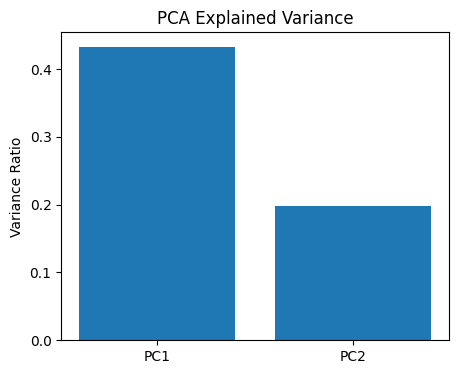

In [ ]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

plt.figure(figsize=(5,4))
plt.bar(["PC1", "PC2"], pca.explained_variance_ratio_)
plt.title("PCA Explained Variance")
plt.ylabel("Variance Ratio")
plt.show()

In [ ]:
lda = LinearDiscriminantAnalysis(n_components=1)

X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

In [ ]:
model_lda = LogisticRegression(max_iter=1000)

model_lda.fit(X_train_lda, y_train)

y_pred_lda = model_lda.predict(X_test_lda)

print("LDA Accuracy:", accuracy_score(y_test, y_pred_lda))

LDA Accuracy: 0.9473684210526315


In [ ]:
print(classification_report(y_test, y_pred_lda))

              precision    recall  f1-score   support

           0       0.97      0.94      0.96        71
           1       0.91      0.95      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



In [ ]:
cm = confusion_matrix(y_test, y_pred_lda)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[67  4]
 [ 2 41]]


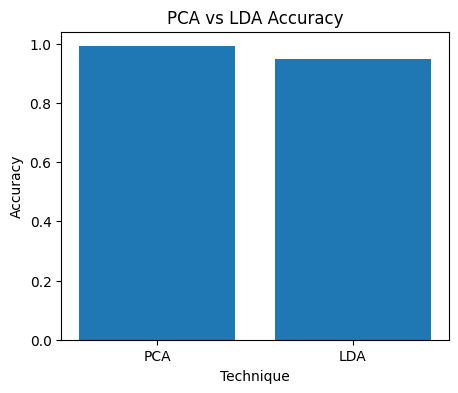

PCA Accuracy: 0.9912280701754386
LDA Accuracy: 0.9473684210526315


In [ ]:
pca_acc = accuracy_score(y_test, y_pred_pca)
lda_acc = accuracy_score(y_test, y_pred_lda)

plt.figure(figsize=(5,4))
plt.bar(["PCA", "LDA"], [pca_acc, lda_acc])

plt.xlabel("Technique")
plt.ylabel("Accuracy")
plt.title("PCA vs LDA Accuracy")

plt.show()

print("PCA Accuracy:", pca_acc)
print("LDA Accuracy:", lda_acc)